# 1.3 CLAP Similarity Margin confidence 평가

## 실험 질문

CLAP embedding 기준으로 현재 label class가 얼마나 명확한가?

이번 실험은 audio/text embedding을 모든 class embedding과 비교해서 margin을 계산한다.

## 핵심 개념

### 1. Top1 - Top2 margin

모든 class embedding과 similarity를 계산한 뒤 가장 높은 class와 두 번째로 높은 class의 차이를 본다.

```text
top1_top2_margin = top1_sim - top2_sim
```

의미:

- margin이 크면 CLAP이 한 class를 비교적 명확하게 고른다.
- margin이 작으면 top1과 top2가 비슷해서 애매하다.

### 2. Assigned label margin

metadata에 적힌 현재 class의 similarity와, 그 class를 제외한 나머지 class 중 최고 similarity의 차이를 본다.

```text
assigned_label_margin = assigned_class_sim - best_other_class_sim
```

의미:

- `> 0`: metadata class가 모든 다른 class보다 더 잘 맞는다.
- `= 0` 근처: metadata class와 다른 class가 비슷하게 맞는다.
- `< 0`: 다른 class가 metadata class보다 더 잘 맞는다. label noise 가능성이 있다.

## 이 노트북에서 계산하는 feature

- `audio_top1_top2_margin`
- `audio_assigned_label_margin`
- `text_top1_top2_margin`
- `text_assigned_label_margin`

confidence와의 관계는 앞선 실험과 같은 방식으로 본다.

- confidence별 Mean ± Std
- confidence별 Boxplot
- margin 5구간 rule-based confidence 분류
- Accuracy / Precision / Recall / F1
- scikit-learn classification report

모든 output은 `deft논문기반_실험/clap_similarity_margin_outputs/` 안에 저장한다.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings('ignore')

HERE = Path.cwd()
if (HERE / '실험계획.md').exists():
    EXP_DIR = HERE
    ROOT = HERE.parent
else:
    ROOT = HERE
    EXP_DIR = ROOT / 'deft논문기반_실험'

AUDIO_EMB_DIR = ROOT / 'data' / 'features' / 'clap_audio_embeddings'
TEXT_EMB_DIR = ROOT / 'data' / 'features' / 'clap_text_embeddings'
CLASS_EMB_DIR = ROOT / 'data' / 'class_embedding'
META_CSV = ROOT / 'data' / 'metadata' / 'BSD10k_metadata.csv'

OUT_DIR = EXP_DIR / 'clap_similarity_margin_outputs'
PLOT_DIR = OUT_DIR / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# 빠른 smoke test가 필요하면 숫자를 넣는다. 전체 실험은 None.
SAMPLE_N = None
SEED = 42
LABELS = [1, 2, 3, 4, 5]

print('ROOT:', ROOT)
print('AUDIO_EMB_DIR:', AUDIO_EMB_DIR, AUDIO_EMB_DIR.exists())
print('TEXT_EMB_DIR :', TEXT_EMB_DIR, TEXT_EMB_DIR.exists())
print('CLASS_EMB_DIR:', CLASS_EMB_DIR, CLASS_EMB_DIR.exists())
print('META_CSV     :', META_CSV, META_CSV.exists())
print('OUT_DIR      :', OUT_DIR)

ROOT: c:\Users\solok\Desktop\Dcase baseline
AUDIO_EMB_DIR: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings True
TEXT_EMB_DIR : c:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings True
CLASS_EMB_DIR: c:\Users\solok\Desktop\Dcase baseline\data\class_embedding True
META_CSV     : c:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv True
OUT_DIR      : c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\clap_similarity_margin_outputs


## 1. 입력 데이터 구성

입력은 세 종류의 embedding이다.

- audio: `data/features/clap_audio_embeddings/{sound_id}.npy`
- text: `data/features/clap_text_embeddings/{sound_id}.npy`
- class: `data/class_embedding/{class}.npy`

`BSD10k_metadata.csv`에서 `sound_id`, `class`, `confidence`를 읽는다.

In [2]:
meta = pd.read_csv(META_CSV)
meta['confidence'] = pd.to_numeric(meta['confidence'], errors='coerce')
meta = meta[meta['confidence'].between(1, 5)].copy()
meta['confidence'] = meta['confidence'].astype(int)

audio_paths = {p.stem: p for p in AUDIO_EMB_DIR.glob('*.npy')}
text_paths = {p.stem: p for p in TEXT_EMB_DIR.glob('*.npy')}
class_paths = {
    p.stem: p
    for p in CLASS_EMB_DIR.glob('*.npy')
    if p.stem.startswith(('m-', 'is-', 'sp-', 'fx-', 'ss-'))
}

df = meta[['sound_id', 'class', 'class_idx', 'class_top', 'confidence', 'title', 'tags', 'description']].copy()
df['sound_id_str'] = df['sound_id'].astype(str)
df['audio_emb_path'] = df['sound_id_str'].map(lambda x: str(audio_paths[x]) if x in audio_paths else None)
df['text_emb_path'] = df['sound_id_str'].map(lambda x: str(text_paths[x]) if x in text_paths else None)
df['assigned_class_emb_path'] = df['class'].map(lambda x: str(class_paths[x]) if x in class_paths else None)

missing_audio = int(df['audio_emb_path'].isna().sum())
missing_text = int(df['text_emb_path'].isna().sum())
missing_class = int(df['assigned_class_emb_path'].isna().sum())
df = df.dropna(subset=['audio_emb_path', 'text_emb_path', 'assigned_class_emb_path']).reset_index(drop=True)

if SAMPLE_N is not None:
    df = df.sample(n=min(SAMPLE_N, len(df)), random_state=SEED).reset_index(drop=True)

mapping_summary = pd.DataFrame([
    {'item': 'metadata rows with confidence', 'count': len(meta)},
    {'item': 'audio embedding files', 'count': len(audio_paths)},
    {'item': 'text embedding files', 'count': len(text_paths)},
    {'item': 'class embedding files', 'count': len(class_paths)},
    {'item': 'missing audio embeddings', 'count': missing_audio},
    {'item': 'missing text embeddings', 'count': missing_text},
    {'item': 'missing class embeddings', 'count': missing_class},
    {'item': 'usable rows', 'count': len(df)},
])

mapping_summary.to_csv(OUT_DIR / 'mapping_summary.csv', index=False, encoding='utf-8-sig')
display(mapping_summary)
display(df[['sound_id', 'class', 'confidence', 'audio_emb_path', 'text_emb_path', 'assigned_class_emb_path']].head())
display(df['confidence'].value_counts().sort_index().rename('count').to_frame())

missing_classes = sorted(set(meta['class']) - set(class_paths))
print('missing class embedding labels:', missing_classes)

,item,count
0,metadata rows with confidence,10956
1,audio embedding files,10956
2,text embedding files,10956
3,class embedding files,23
4,missing audio embeddings,0
5,missing text embeddings,0
6,missing class embeddings,0
7,usable rows,10956


,sound_id,class,confidence,audio_emb_path,text_emb_path,assigned_class_emb_path
0,185755,fx-o,4,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\cla...
1,358405,is-w,5,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\cla...
2,358760,is-w,4,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\cla...
3,432206,fx-o,4,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\cla...
4,80630,sp-s,5,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\cla...


,count
confidence,
1,106
2,749
3,3280
4,6045
5,776


missing class embedding labels: []


## 2. Class embedding matrix 준비

모든 class embedding을 하나의 matrix로 쌓고 normalize한다. 이후 audio/text embedding과 matrix multiplication으로 모든 class similarity를 한 번에 계산한다.

In [3]:
def load_vector(path):
    return np.load(path).astype(np.float32).reshape(-1)

def l2_normalize(vec):
    norm = float(np.linalg.norm(vec))
    if norm == 0.0:
        return vec
    return vec / norm

class_labels = sorted(class_paths.keys())
class_matrix = np.stack([l2_normalize(load_vector(class_paths[label])) for label in class_labels])
class_to_index = {label: idx for idx, label in enumerate(class_labels)}

print('num classes:', len(class_labels))
print(class_labels)
print('class_matrix shape:', class_matrix.shape)

num classes: 23
['fx-a', 'fx-el', 'fx-ex', 'fx-h', 'fx-m', 'fx-n', 'fx-o', 'fx-v', 'is-e', 'is-k', 'is-p', 'is-s', 'is-w', 'm-m', 'm-si', 'm-sp', 'sp-c', 'sp-p', 'sp-s', 'ss-i', 'ss-n', 'ss-s', 'ss-u']
class_matrix shape: (23, 512)


## 3. Margin 계산

audio embedding과 text embedding 각각에 대해 모든 class similarity를 계산한다.

저장하는 값:

- top1 class / top1 sim
- top2 class / top2 sim
- top1_top2_margin
- assigned_class_sim
- best_other_class / best_other_sim
- assigned_label_margin
- assigned class rank
- top1이 metadata class와 같은지

In [4]:
def margin_features(vec_path, assigned_class):
    vec = l2_normalize(load_vector(vec_path))
    sims = class_matrix @ vec

    sorted_idx = np.argsort(sims)[::-1]
    top1_idx = int(sorted_idx[0])
    top2_idx = int(sorted_idx[1])

    assigned_idx = class_to_index[assigned_class]
    other_idx = [idx for idx in range(len(class_labels)) if idx != assigned_idx]
    best_other_idx = max(other_idx, key=lambda idx: sims[idx])

    assigned_rank = int(np.where(sorted_idx == assigned_idx)[0][0]) + 1

    return {
        'top1_class': class_labels[top1_idx],
        'top1_sim': float(sims[top1_idx]),
        'top2_class': class_labels[top2_idx],
        'top2_sim': float(sims[top2_idx]),
        'top1_top2_margin': float(sims[top1_idx] - sims[top2_idx]),
        'assigned_class_sim': float(sims[assigned_idx]),
        'best_other_class': class_labels[best_other_idx],
        'best_other_sim': float(sims[best_other_idx]),
        'assigned_label_margin': float(sims[assigned_idx] - sims[best_other_idx]),
        'assigned_rank': assigned_rank,
        'top1_matches_assigned': bool(class_labels[top1_idx] == assigned_class),
    }

audio_rows = []
text_rows = []
failed = []

for row in df.to_dict('records'):
    try:
        audio_feat = margin_features(row['audio_emb_path'], row['class'])
        text_feat = margin_features(row['text_emb_path'], row['class'])
        audio_rows.append(audio_feat)
        text_rows.append(text_feat)
    except Exception as exc:
        audio_rows.append({})
        text_rows.append({})
        failed.append({'sound_id': row['sound_id'], 'class': row['class'], 'error': str(exc)})

audio_feat_df = pd.DataFrame(audio_rows).add_prefix('audio_')
text_feat_df = pd.DataFrame(text_rows).add_prefix('text_')

df = pd.concat([df.reset_index(drop=True), audio_feat_df, text_feat_df], axis=1)
df = df.dropna(subset=['audio_assigned_label_margin', 'text_assigned_label_margin']).reset_index(drop=True)

if failed:
    pd.DataFrame(failed).to_csv(OUT_DIR / 'failed_margin_rows.csv', index=False, encoding='utf-8-sig')

df.to_csv(OUT_DIR / 'clap_similarity_margin_features.csv', index=False, encoding='utf-8-sig')

print('usable rows:', len(df))
print('failed rows:', len(failed))
display(df[[
    'sound_id', 'class', 'confidence',
    'audio_top1_class', 'audio_top2_class', 'audio_top1_top2_margin', 'audio_assigned_label_margin', 'audio_assigned_rank',
    'text_top1_class', 'text_top2_class', 'text_top1_top2_margin', 'text_assigned_label_margin', 'text_assigned_rank'
]].head())

usable rows: 10956
failed rows: 0


,sound_id,class,confidence,audio_top1_class,audio_top2_class,audio_top1_top2_margin,audio_assigned_label_margin,audio_assigned_rank,text_top1_class,text_top2_class,text_top1_top2_margin,text_assigned_label_margin,text_assigned_rank
0,185755,fx-o,4,fx-o,is-k,0.046245,0.046245,1,fx-o,is-s,0.045049,0.045049,1
1,358405,is-w,5,is-w,ss-n,0.004585,0.004585,1,m-si,m-sp,0.124001,-0.182870,3
2,358760,is-w,4,m-si,m-sp,0.102435,-0.245459,9,m-si,m-sp,0.179720,-0.280030,5
3,432206,fx-o,4,m-sp,is-p,0.090603,-0.360327,22,sp-c,is-p,0.030404,-0.295929,23
4,80630,sp-s,5,sp-s,is-p,0.072325,0.072325,1,fx-h,ss-n,0.055346,-0.093477,7


## 4. Top1 class가 metadata class와 일치하는지 확인

margin 해석 전, CLAP 기준 top1 class가 실제 metadata class와 얼마나 자주 일치하는지 확인한다.

In [5]:
top1_summary = pd.DataFrame([
    {
        'feature_source': 'audio',
        'top1_matches_assigned_rate': float(df['audio_top1_matches_assigned'].mean()),
        'assigned_rank_mean': float(df['audio_assigned_rank'].mean()),
        'assigned_rank_median': float(df['audio_assigned_rank'].median()),
    },
    {
        'feature_source': 'text',
        'top1_matches_assigned_rate': float(df['text_top1_matches_assigned'].mean()),
        'assigned_rank_mean': float(df['text_assigned_rank'].mean()),
        'assigned_rank_median': float(df['text_assigned_rank'].median()),
    },
])

top1_summary.to_csv(OUT_DIR / 'top1_assigned_match_summary.csv', index=False, encoding='utf-8-sig')
display(top1_summary.round(4))

,feature_source,top1_matches_assigned_rate,assigned_rank_mean,assigned_rank_median
0,audio,0.1836,7.3815,5.0
1,text,0.1832,7.2912,5.0


## 5. Confidence별 Mean ± Std와 Boxplot

각 margin feature가 confidence별로 어떻게 움직이는지 본다.

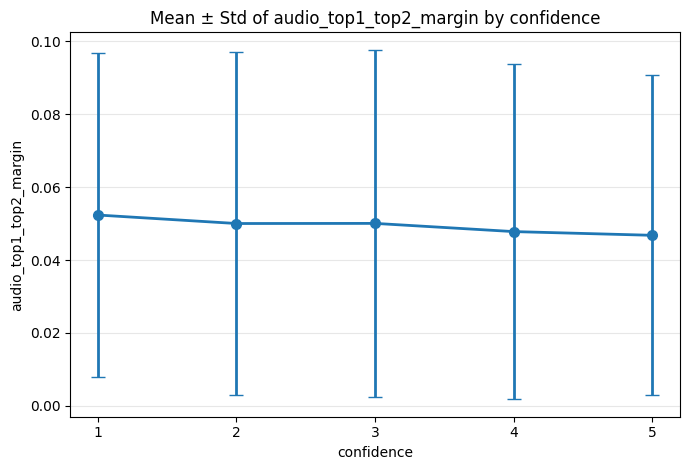

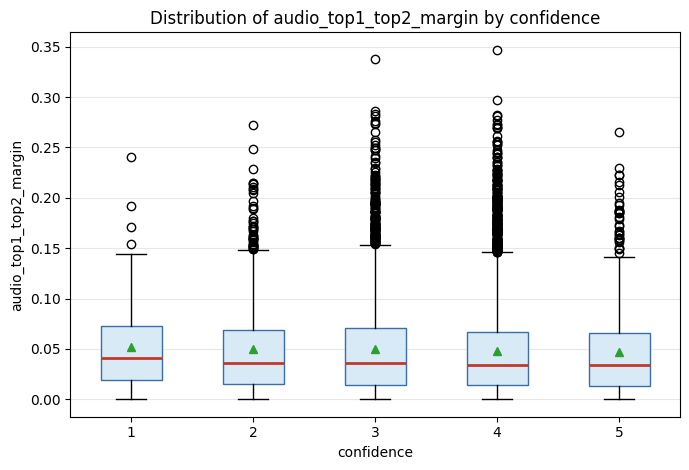

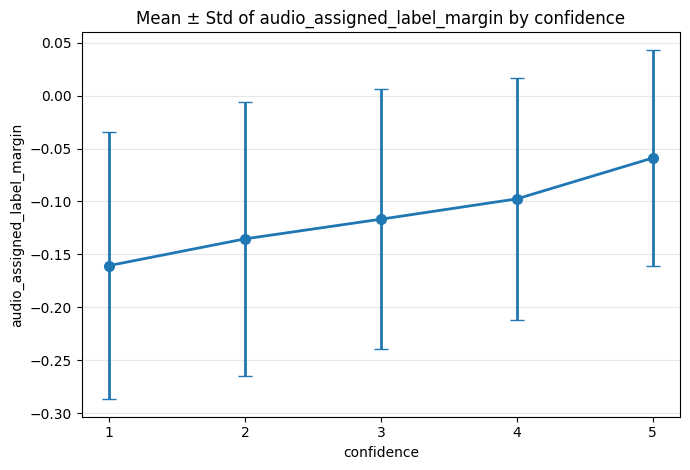

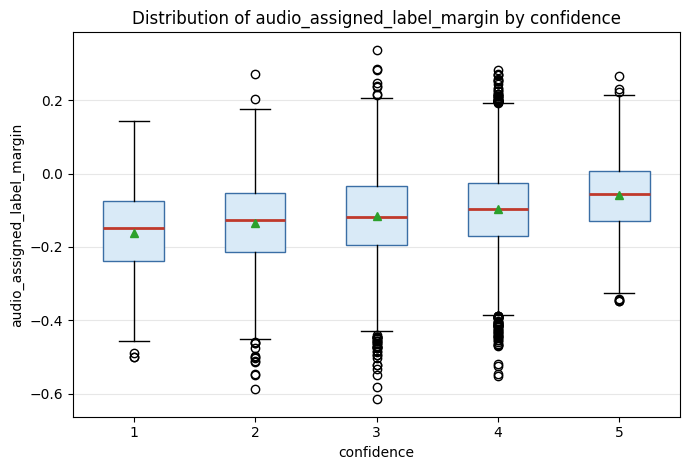

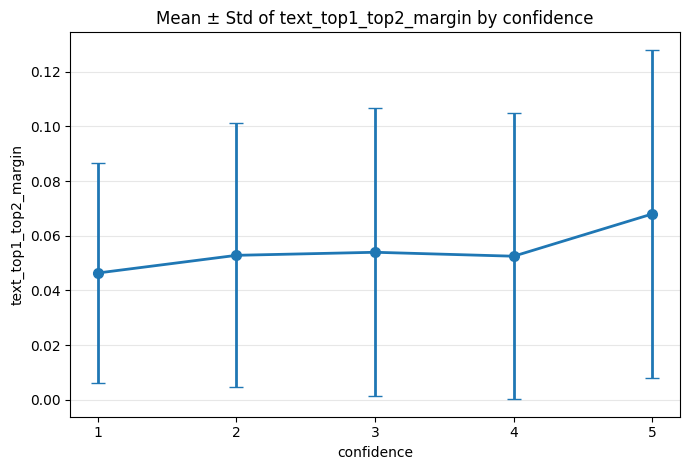

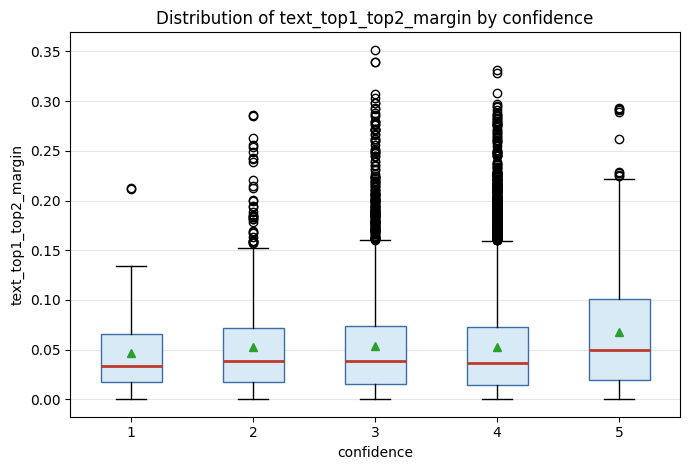

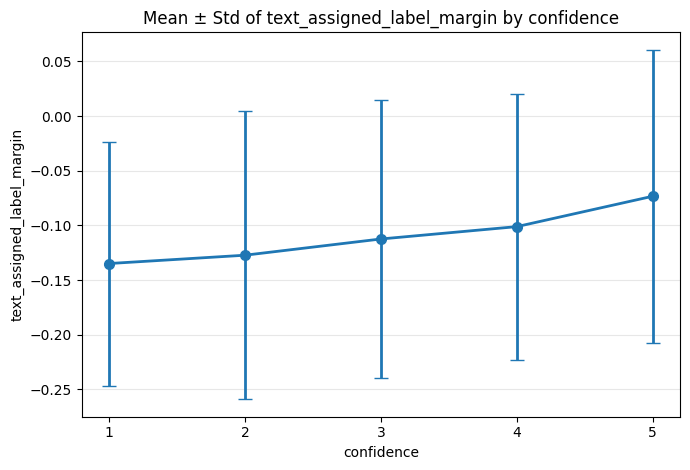

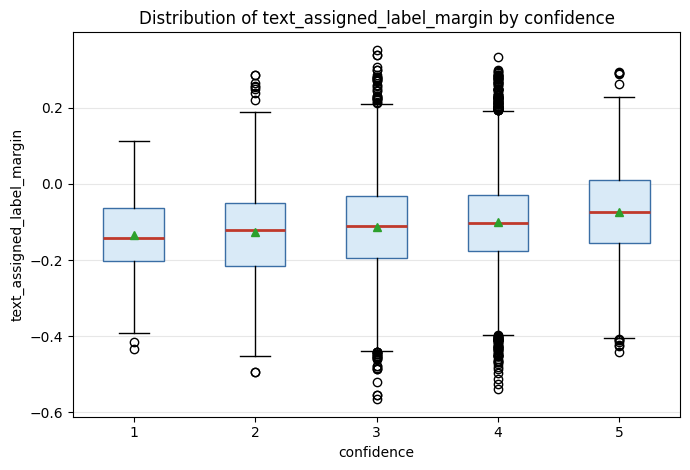

,feature,confidence,n,mean,std,median,q1,q3
0,audio_top1_top2_margin,1,106,0.0523,0.0444,0.0413,0.0194,0.0724
1,audio_top1_top2_margin,2,749,0.0500,0.0471,0.0363,0.0151,0.0687
2,audio_top1_top2_margin,3,3280,0.0500,0.0476,0.0356,0.0143,0.0703
3,audio_top1_top2_margin,4,6045,0.0478,0.0459,0.0336,0.0140,0.0670
4,audio_top1_top2_margin,5,776,0.0468,0.0438,0.0336,0.0136,0.0656
5,audio_assigned_label_margin,1,106,-0.1606,0.1263,-0.1497,-0.2391,-0.0748
6,audio_assigned_label_margin,2,749,-0.1354,0.1291,-0.1270,-0.2141,-0.0531
7,audio_assigned_label_margin,3,3280,-0.1168,0.1230,-0.1172,-0.1955,-0.0347
8,audio_assigned_label_margin,4,6045,-0.0976,0.1145,-0.0969,-0.1696,-0.0246
9,audio_assigned_label_margin,5,776,-0.0589,0.1022,-0.0556,-0.1288,0.0081


In [6]:
MARGIN_FEATURES = [
    'audio_top1_top2_margin',
    'audio_assigned_label_margin',
    'text_top1_top2_margin',
    'text_assigned_label_margin',
]

all_confidence_stats = []

for feature in MARGIN_FEATURES:
    stats = df.groupby('confidence').agg(
        n=(feature, 'size'),
        mean=(feature, 'mean'),
        std=(feature, 'std'),
        median=(feature, 'median'),
        q1=(feature, lambda s: s.quantile(0.25)),
        q3=(feature, lambda s: s.quantile(0.75)),
    ).reset_index()
    stats.insert(0, 'feature', feature)
    all_confidence_stats.append(stats)

    stats.to_csv(OUT_DIR / f'{feature}_confidence_mean_std.csv', index=False, encoding='utf-8-sig')

    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.errorbar(
        stats['confidence'],
        stats['mean'],
        yerr=stats['std'],
        fmt='o-',
        capsize=5,
        linewidth=2,
        markersize=7,
    )
    ax.set_title(f'Mean ± Std of {feature} by confidence')
    ax.set_xlabel('confidence')
    ax.set_ylabel(feature)
    ax.set_xticks(LABELS)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'{feature}_mean_std.png', dpi=200)
    plt.show()

    plot_data = [df.loc[df['confidence'] == c, feature].values for c in LABELS]
    fig, ax = plt.subplots(figsize=(7, 4.8))
    box = ax.boxplot(plot_data, labels=LABELS, showmeans=True, patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor('#D9EAF7')
        patch.set_edgecolor('#3A6EA5')
    for median in box['medians']:
        median.set_color('#C0392B')
        median.set_linewidth(2)
    ax.set_title(f'Distribution of {feature} by confidence')
    ax.set_xlabel('confidence')
    ax.set_ylabel(feature)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'{feature}_boxplot.png', dpi=200)
    plt.show()

confidence_stats = pd.concat(all_confidence_stats, ignore_index=True)
confidence_stats.to_csv(OUT_DIR / 'all_margin_confidence_mean_std.csv', index=False, encoding='utf-8-sig')
display(confidence_stats.round(4))

## 6. Margin 5구간 분류 평가

각 margin feature를 낮은 값부터 높은 값까지 5개 분위수 구간으로 나누고, 구간을 predicted confidence 1-5로 매핑한다.

In [7]:
def evaluate_margin_feature(data, feature):
    tmp = data[['sound_id', 'confidence', feature]].dropna().copy()
    bin_labels = ['Q1_pred_1', 'Q2_pred_2', 'Q3_pred_3', 'Q4_pred_4', 'Q5_pred_5']
    tmp['sim_bin'] = pd.qcut(tmp[feature], q=5, labels=bin_labels, duplicates='drop')
    bin_to_pred = {label: idx + 1 for idx, label in enumerate(bin_labels)}
    tmp['pred_confidence_from_margin'] = tmp['sim_bin'].map(bin_to_pred).astype(int)

    bin_ranges = tmp.groupby('sim_bin', observed=True).agg(
        predicted_confidence=('pred_confidence_from_margin', 'first'),
        n=('sound_id', 'count'),
        margin_min=(feature, 'min'),
        margin_mean=(feature, 'mean'),
        margin_max=(feature, 'max'),
    ).reset_index()

    count_table = pd.crosstab(
        tmp['pred_confidence_from_margin'],
        tmp['confidence'],
        rownames=['predicted_by_margin'],
        colnames=['true_confidence'],
    ).reindex(index=LABELS, columns=LABELS, fill_value=0)

    ratio_table = pd.crosstab(
        tmp['pred_confidence_from_margin'],
        tmp['confidence'],
        normalize='index',
        rownames=['predicted_by_margin'],
        colnames=['true_confidence'],
    ).reindex(index=LABELS, columns=LABELS, fill_value=0)

    y_true = tmp['confidence'].astype(int)
    y_pred = tmp['pred_confidence_from_margin'].astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, average='macro', zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, average='weighted', zero_division=0
    )

    metric_row = {
        'feature': feature,
        'accuracy': accuracy,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
    }

    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=LABELS),
        index=[f'true_{x}' for x in LABELS],
        columns=[f'pred_{x}' for x in LABELS],
    )

    report_text = classification_report(
        y_true,
        y_pred,
        labels=LABELS,
        target_names=[f'confidence_{x}' for x in LABELS],
        zero_division=0,
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=LABELS,
        target_names=[f'confidence_{x}' for x in LABELS],
        output_dict=True,
        zero_division=0,
    )

    prefix = feature
    tmp.to_csv(OUT_DIR / f'{prefix}_with_bin_predictions.csv', index=False, encoding='utf-8-sig')
    bin_ranges.to_csv(OUT_DIR / f'{prefix}_bin_ranges.csv', index=False, encoding='utf-8-sig')
    count_table.to_csv(OUT_DIR / f'{prefix}_true_confidence_counts.csv', encoding='utf-8-sig')
    ratio_table.to_csv(OUT_DIR / f'{prefix}_true_confidence_ratios.csv', encoding='utf-8-sig')
    cm.to_csv(OUT_DIR / f'{prefix}_confusion_matrix.csv', encoding='utf-8-sig')
    (OUT_DIR / f'{prefix}_classification_report.txt').write_text(report_text, encoding='utf-8')
    pd.DataFrame(report_dict).T.to_csv(OUT_DIR / f'{prefix}_classification_report.csv', encoding='utf-8-sig')

    return metric_row, bin_ranges, count_table, ratio_table, cm, report_text

metric_rows = []
evaluation_tables = {}

for feature in MARGIN_FEATURES:
    result = evaluate_margin_feature(df, feature)
    metric_row, bin_ranges, count_table, ratio_table, cm, report_text = result
    metric_rows.append(metric_row)
    evaluation_tables[feature] = {
        'bin_ranges': bin_ranges,
        'count_table': count_table,
        'ratio_table': ratio_table,
        'confusion_matrix': cm,
        'report_text': report_text,
    }

margin_metric_summary = pd.DataFrame(metric_rows)
margin_metric_summary.to_csv(OUT_DIR / 'margin_5bin_metrics.csv', index=False, encoding='utf-8-sig')
display(margin_metric_summary.round(4))

for feature in MARGIN_FEATURES:
    print('\n' + '=' * 80)
    print(feature)
    print('=' * 80)
    print('Bin ranges')
    display(evaluation_tables[feature]['bin_ranges'].round(4))
    print('Counts: predicted confidence by margin bin vs true confidence')
    display(evaluation_tables[feature]['count_table'])
    print(evaluation_tables[feature]['report_text'])

,feature,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,audio_top1_top2_margin,0.1907,0.1907,0.1831,0.1434,0.3885,0.1907,0.2380
1,audio_assigned_label_margin,0.2090,0.2090,0.2518,0.1646,0.4118,0.2090,0.2535
2,text_top1_top2_margin,0.2019,0.2019,0.2144,0.1596,0.3920,0.2019,0.2442
3,text_assigned_label_margin,0.2066,0.2067,0.2260,0.1612,0.4080,0.2066,0.2521



audio_top1_top2_margin
Bin ranges


,sim_bin,predicted_confidence,n,margin_min,margin_mean,margin_max
0,Q1_pred_1,1,2192,0.0000,0.0053,0.0110
1,Q2_pred_2,2,2191,0.0110,0.0179,0.0257
2,Q3_pred_3,3,2191,0.0257,0.0349,0.0451
3,Q4_pred_4,4,2191,0.0451,0.0602,0.0794
4,Q5_pred_5,5,2191,0.0794,0.1247,0.3469


Counts: predicted confidence by margin bin vs true confidence


true_confidence,1,2,3,4,5
predicted_by_margin,,,,,
1,17,144,636,1239,156
2,14,147,661,1218,151
3,28,156,613,1233,161
4,24,143,680,1174,170
5,23,159,690,1181,138


...

              precision    recall  f1-score   support

confidence_1       0.01      0.17      0.02       106
confidence_2       0.07      0.20      0.10       749
confidence_3       0.29      0.20      0.23      3280
confidence_4       0.53      0.19      0.28      6045
confidence_5       0.11      0.31      0.16       776

    accuracy                           0.20     10956
   macro avg       0.20      0.21      0.16     10956
weighted avg       0.39      0.20      0.24     10956


text_assigned_label_margin
Bin ranges


,sim_bin,predicted_confidence,n,margin_min,margin_mean,margin_max
0,Q1_pred_1,1,2192,-0.5652,-0.2787,-0.2052
1,Q2_pred_2,2,2191,-0.2051,-0.1669,-0.1345
2,Q3_pred_3,3,2192,-0.1344,-0.1046,-0.0767
3,Q4_pred_4,4,2190,-0.0767,-0.0446,-0.0083
4,Q5_pred_5,5,2191,-0.0082,0.0718,0.3516


Counts: predicted confidence by margin bin vs true confidence


true_confidence,1,2,3,4,5
predicted_by_margin,,,,,
1,26,200,732,1103,131
2,33,148,647,1248,115
3,17,136,642,1258,139
4,16,139,644,1224,167
5,14,126,615,1212,224


              precision    recall  f1-score   support

confidence_1       0.01      0.25      0.02       106
confidence_2       0.07      0.20      0.10       749
confidence_3       0.29      0.20      0.23      3280
confidence_4       0.56      0.20      0.30      6045
confidence_5       0.10      0.29      0.15       776

    accuracy                           0.21     10956
   macro avg       0.21      0.23      0.16     10956
weighted avg       0.41      0.21      0.25     10956



## 6-1. 5구간 분류표 해석

위 count table은 다음 질문을 보기 위한 표다.

```text
margin이 낮은 20%를 confidence 1이라고 보고,
margin이 높은 20%를 confidence 5라고 보면,
실제 confidence도 그에 맞게 1,2,3,4,5로 모이는가?
```

행은 margin 기반 예측 confidence이고, 열은 실제 confidence다.

좋은 결과라면 대각선이 커야 한다.

```text
pred 1 -> true 1이 많음
pred 2 -> true 2가 많음
pred 3 -> true 3이 많음
pred 4 -> true 4가 많음
pred 5 -> true 5가 많음
```

하지만 이 데이터는 confidence 4가 압도적으로 많고 confidence 1은 약 100개 수준이라, 정확한 1~5 분류표는 매우 불리하다. 그래서 이 표는 보통 `정확히 몇 클래스를 맞췄나`보다 `높은 margin 구간으로 갈수록 confidence 5 또는 confidence 4/5가 늘어나는가`를 같이 봐야 한다.

In [8]:
interpretation_rows = []

for feature in MARGIN_FEATURES:
    counts = evaluation_tables[feature]['count_table']
    row_pct = counts.div(counts.sum(axis=1), axis=0).fillna(0)
    col_pct = counts.div(counts.sum(axis=0), axis=1).fillna(0)

    q1_high_conf_rate = float(row_pct.loc[1, [4, 5]].sum())
    q5_high_conf_rate = float(row_pct.loc[5, [4, 5]].sum())
    q1_conf5_rate = float(row_pct.loc[1, 5])
    q5_conf5_rate = float(row_pct.loc[5, 5])
    q1_conf1_capture = float(col_pct.loc[1, 1])
    q5_conf5_capture = float(col_pct.loc[5, 5])
    diagonal_acc_from_counts = float(np.trace(counts.values) / counts.values.sum())

    interpretation_rows.append({
        'feature': feature,
        'q1_high_conf_4_5_rate': q1_high_conf_rate,
        'q5_high_conf_4_5_rate': q5_high_conf_rate,
        'delta_q5_minus_q1_high_conf_rate': q5_high_conf_rate - q1_high_conf_rate,
        'q1_conf5_rate': q1_conf5_rate,
        'q5_conf5_rate': q5_conf5_rate,
        'delta_q5_minus_q1_conf5_rate': q5_conf5_rate - q1_conf5_rate,
        'true_conf1_captured_by_pred1_rate': q1_conf1_capture,
        'true_conf5_captured_by_pred5_rate': q5_conf5_capture,
        'exact_5class_accuracy_from_table': diagonal_acc_from_counts,
    })

interpretation_summary = pd.DataFrame(interpretation_rows)
interpretation_summary.to_csv(OUT_DIR / 'margin_table_interpretation_summary.csv', index=False, encoding='utf-8-sig')
display(interpretation_summary.round(4))

for feature in MARGIN_FEATURES:
    row = interpretation_summary[interpretation_summary['feature'] == feature].iloc[0]
    print('\n' + '=' * 80)
    print(feature)
    print('=' * 80)
    print(f"Q1 high-confidence(4/5) rate: {row['q1_high_conf_4_5_rate']:.2%}")
    print(f"Q5 high-confidence(4/5) rate: {row['q5_high_conf_4_5_rate']:.2%}")
    print(f"Q5 - Q1 high-confidence gain: {row['delta_q5_minus_q1_high_conf_rate']:.2%}")
    print(f"Q1 confidence-5 rate: {row['q1_conf5_rate']:.2%}")
    print(f"Q5 confidence-5 rate: {row['q5_conf5_rate']:.2%}")
    print(f"Q5 - Q1 confidence-5 gain: {row['delta_q5_minus_q1_conf5_rate']:.2%}")
    print(f"Exact 5-class accuracy from bins: {row['exact_5class_accuracy_from_table']:.2%}")
    print('해석: 정확한 1~5 분류 성능보다, Q5로 갈수록 confidence 4/5 또는 5 비율이 증가하는지를 본다.')

,feature,q1_high_conf_4_5_rate,q5_high_conf_4_5_rate,delta_q5_minus_q1_high_conf_rate,q1_conf5_rate,q5_conf5_rate,delta_q5_minus_q1_conf5_rate,true_conf1_captured_by_pred1_rate,true_conf5_captured_by_pred5_rate,exact_5class_accuracy_from_table
0,audio_top1_top2_margin,0.6364,0.6020,-0.0344,0.0712,0.0630,-0.0082,0.1604,0.1778,0.1907
1,audio_assigned_label_margin,0.5224,0.6737,0.1513,0.0328,0.1059,0.0730,0.3585,0.2990,0.2090
2,text_top1_top2_margin,0.6387,0.6372,-0.0015,0.0570,0.1114,0.0543,0.1698,0.3144,0.2019
3,text_assigned_label_margin,0.5630,0.6554,0.0925,0.0598,0.1022,0.0425,0.2453,0.2887,0.2066



audio_top1_top2_margin
Q1 high-confidence(4/5) rate: 63.64%
Q5 high-confidence(4/5) rate: 60.20%
Q5 - Q1 high-confidence gain: -3.44%
Q1 confidence-5 rate: 7.12%
Q5 confidence-5 rate: 6.30%
Q5 - Q1 confidence-5 gain: -0.82%
Exact 5-class accuracy from bins: 19.07%
해석: 정확한 1~5 분류 성능보다, Q5로 갈수록 confidence 4/5 또는 5 비율이 증가하는지를 본다.

audio_assigned_label_margin
Q1 high-confidence(4/5) rate: 52.24%
Q5 high-confidence(4/5) rate: 67.37%
Q5 - Q1 high-confidence gain: 15.13%
Q1 confidence-5 rate: 3.28%
Q5 confidence-5 rate: 10.59%
Q5 - Q1 confidence-5 gain: 7.30%
Exact 5-class accuracy from bins: 20.90%
해석: 정확한 1~5 분류 성능보다, Q5로 갈수록 confidence 4/5 또는 5 비율이 증가하는지를 본다.

text_top1_top2_margin
Q1 high-confidence(4/5) rate: 63.87%
Q5 high-confidence(4/5) rate: 63.72%
Q5 - Q1 high-confidence gain: -0.15%
Q1 confidence-5 rate: 5.70%
Q5 confidence-5 rate: 11.14%
Q5 - Q1 confidence-5 gain: 5.43%
Exact 5-class accuracy from bins: 20.19%
해석: 정확한 1~5 분류 성능보다, Q5로 갈수록 confidence 4/5 또는 5 비율이 증가하는지를 본다.

text_

## 7. Summary metrics 생성

In [9]:
summary_rows = []

for feature in MARGIN_FEATURES:
    means = confidence_stats[confidence_stats['feature'] == feature].set_index('confidence')['mean']
    metric = margin_metric_summary[margin_metric_summary['feature'] == feature].iloc[0]
    summary_rows.append({
        'feature': feature,
        'is_mean_monotonic_increasing': bool((means.diff().dropna() >= 0).all()),
        'confidence_5_mean_minus_confidence_1_mean': float(means.loc[5] - means.loc[1]),
        'confidence_5_mean_minus_confidence_4_mean': float(means.loc[5] - means.loc[4]),
        'similarity_5bin_accuracy': float(metric['accuracy']),
        'similarity_5bin_macro_precision': float(metric['macro_precision']),
        'similarity_5bin_macro_recall': float(metric['macro_recall']),
        'similarity_5bin_macro_f1': float(metric['macro_f1']),
        'similarity_5bin_weighted_precision': float(metric['weighted_precision']),
        'similarity_5bin_weighted_recall': float(metric['weighted_recall']),
        'similarity_5bin_weighted_f1': float(metric['weighted_f1']),
    })

summary_metrics = pd.DataFrame(summary_rows)
summary_metrics.to_csv(OUT_DIR / 'summary_metrics.csv', index=False, encoding='utf-8-sig')
display(summary_metrics.round(4))

,feature,is_mean_monotonic_increasing,confidence_5_mean_minus_confidence_1_mean,confidence_5_mean_minus_confidence_4_mean,similarity_5bin_accuracy,similarity_5bin_macro_precision,similarity_5bin_macro_recall,similarity_5bin_macro_f1,similarity_5bin_weighted_precision,similarity_5bin_weighted_recall,similarity_5bin_weighted_f1
0,audio_top1_top2_margin,False,-0.0056,-0.0010,0.1907,0.1907,0.1831,0.1434,0.3885,0.1907,0.2380
1,audio_assigned_label_margin,True,0.1017,0.0387,0.2090,0.2090,0.2518,0.1646,0.4118,0.2090,0.2535
2,text_top1_top2_margin,False,0.0216,0.0155,0.2019,0.2019,0.2144,0.1596,0.3920,0.2019,0.2442
3,text_assigned_label_margin,True,0.0616,0.0278,0.2066,0.2067,0.2260,0.1612,0.4080,0.2066,0.2521


## 8. 리포트 저장

In [10]:
def table_text(table, index=False):
    return table.round(4).to_string(index=index)

report_lines = []
report_lines.append('# CLAP similarity margin confidence 평가 결과')
report_lines.append('')
report_lines.append('## Margin definitions')
report_lines.append('- top1_top2_margin = top1_sim - top2_sim')
report_lines.append('- assigned_label_margin = assigned_class_sim - best_other_class_sim')
report_lines.append('')
report_lines.append('## Top1 assigned-class match summary')
report_lines.append('```text')
report_lines.append(table_text(top1_summary, index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## Summary metrics')
report_lines.append('```text')
report_lines.append(table_text(summary_metrics, index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## Confidence별 Mean ± Std')
report_lines.append('```text')
report_lines.append(table_text(confidence_stats, index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## Margin 5-bin metrics')
report_lines.append('```text')
report_lines.append(table_text(margin_metric_summary, index=False))
report_lines.append('```')

for feature in MARGIN_FEATURES:
    report_lines.append('')
    report_lines.append(f'## {feature}')
    report_lines.append('### Bin ranges')
    report_lines.append('```text')
    report_lines.append(table_text(evaluation_tables[feature]['bin_ranges'], index=False))
    report_lines.append('```')
    report_lines.append('### True confidence counts')
    report_lines.append('```text')
    report_lines.append(table_text(evaluation_tables[feature]['count_table'], index=True))
    report_lines.append('```')
    report_lines.append('### Classification report')
    report_lines.append('```text')
    report_lines.append(evaluation_tables[feature]['report_text'])
    report_lines.append('```')

summary_json = {
    'output_dir': str(OUT_DIR),
    'features': MARGIN_FEATURES,
    'top1_summary': top1_summary.to_dict(orient='records'),
    'summary_metrics': summary_metrics.to_dict(orient='records'),
}

(OUT_DIR / 'summary.json').write_text(json.dumps(summary_json, indent=2, ensure_ascii=False), encoding='utf-8')
(OUT_DIR / 'clap_similarity_margin_report.md').write_text('\n'.join(report_lines), encoding='utf-8')

print('saved:', OUT_DIR / 'clap_similarity_margin_report.md')
print('saved:', OUT_DIR / 'summary.json')

saved: c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\clap_similarity_margin_outputs\clap_similarity_margin_report.md
saved: c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\clap_similarity_margin_outputs\summary.json
